# **About Dataset**
## **Description:**
- This dataset contains information about bank customers and their churn status, which indicates whether they have exited the bank or not. It is suitable for exploring and analyzing factors influencing customer churn in banking institutions and for building predictive models to identify customers at risk of churning.

## **Features:**
#### **RowNumber:**  The sequential number assigned to each row in the dataset.

#### **CustomerId:** A unique identifier for each customer.

#### **Surname:** The surname of the customer.

#### **CreditScore:**   The credit score of the customer.

#### **Geography:** The geographical location of the customer (e.g., country or region).

#### **Gender:** The gender of the customer.

#### **Age:** The age of the customer.

#### **Tenure:** The number of years the customer has been with the bank.

#### **Balance:** The account balance of the customer.

#### **NumOfProducts:**  The number of bank products the customer has.

#### **HasCrCard:**  Indicates whether the customer has a credit card (binary: yes/no).

#### **IsActiveMember:**  Indicates whether the customer is an active member (binary: yes/no).

#### **EstimatedSalary:** The estimated salary of the customer.

#### **Exited:**  Indicates whether the customer has exited the bank (binary: yes/no).

In [231]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [232]:
path = (r"C:\Customer_churn_prediction\Dataset\Churn_bank_modeling.csv")
df = pd.read_csv(path)

In [233]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [234]:
df.drop(['CustomerId', 'Surname', 'RowNumber'], axis = 1, inplace = True)

In [235]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 966.1 KB


In [236]:
df.dtypes

CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [237]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

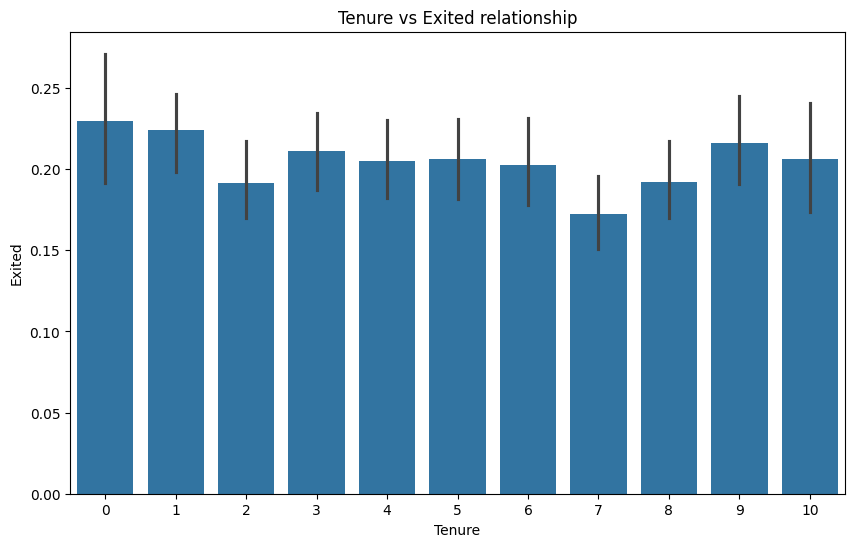

In [238]:
plt.figure(figsize=(10,6))
sns.barplot(x = 'Tenure', y = 'Exited', data = df)
plt.title('Tenure vs Exited relationship')
plt.xlabel('Tenure')
plt.ylabel('Exited')
plt.savefig(r'C:\Customer_churn_prediction\coading_part\data_visulzation\Bank_Tenure vs Exited relationship.png')
plt.show()

In [239]:
df[['EstimatedSalary','Balance']].astype('int64')

,EstimatedSalary,Balance
0,101348,0
1,112542,83807
2,113931,159660
3,93826,0
4,79084,125510
...,...,...
9995,96270,0
9996,101699,57369
9997,42085,0
9998,92888,75075


In [240]:
cat_col = df.select_dtypes(include='object').columns
cat_col

C:\Users\ajsah\AppData\Local\Temp\ipykernel_11008\113230759.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df.select_dtypes(include='object').columns


Index(['Geography', 'Gender'], dtype='str')

In [241]:
num_col = df.select_dtypes(include=['int64', 'float64']).columns
num_col

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

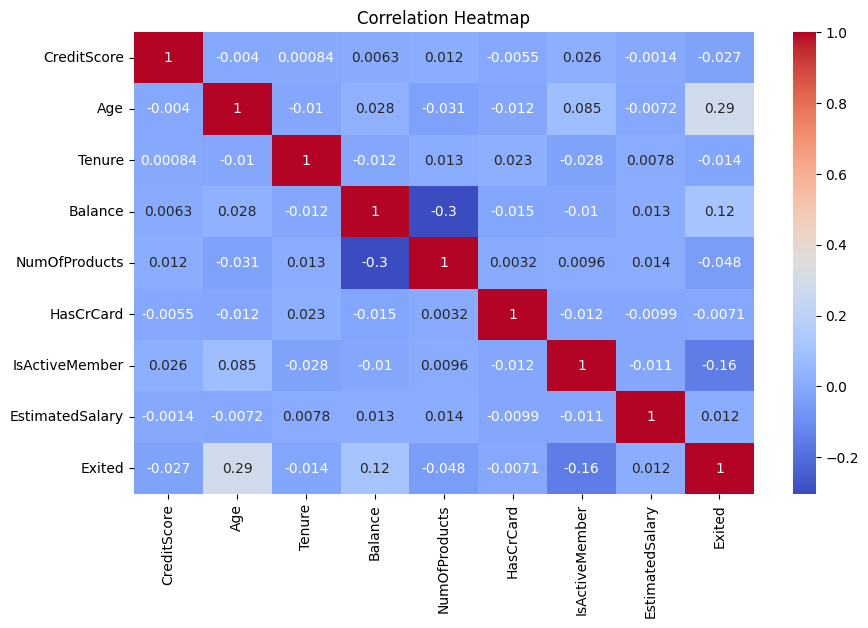

In [242]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_col].corr(), annot = True, cmap = 'coolwarm')
plt.Arrow(0, 0, 1, 1, color='black', width=0.5)
plt.title('Correlation Heatmap')
plt.savefig(r'C:\Customer_churn_prediction\coading_part\data_visulzation\Bank_Correlation Heatmap.png')
plt.show()

# **Visualizing Patterns and Relationships**
The following plots help identify customer churn patterns across geography, gender, age, balance, salary, product usage, and active membership.

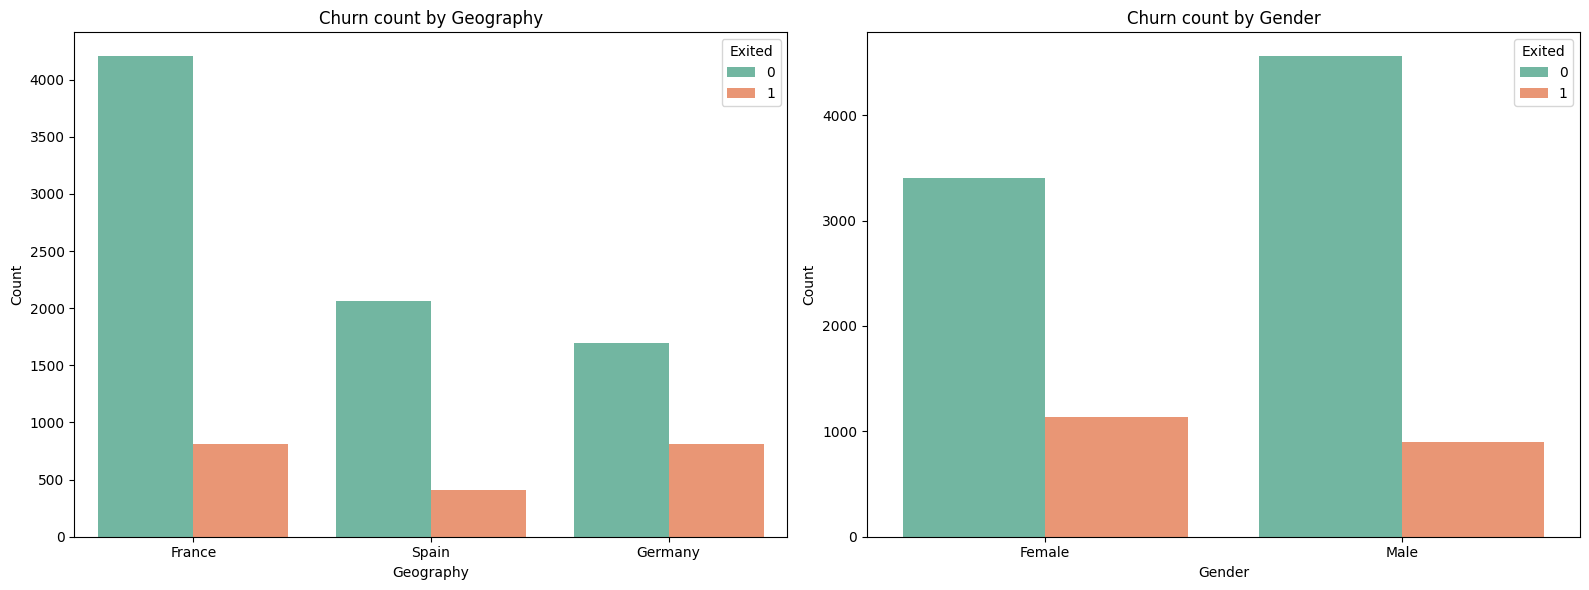

In [243]:
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sns.countplot(x='Geography', hue='Exited', data=df, palette='Set2')
plt.title('Churn count by Geography')
plt.xlabel('Geography')
plt.ylabel('Count')
plt.subplot(1,2,2)
sns.countplot(x='Gender', hue='Exited', data=df, palette='Set2')
plt.title('Churn count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(r'C:\Customer_churn_prediction\coading_part\data_visulzation\Bank_Churn by Geography and Gender.png')
plt.show()

C:\Users\ajsah\AppData\Local\Temp\ipykernel_11008\2768526993.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Age', data=df, palette='Set3')


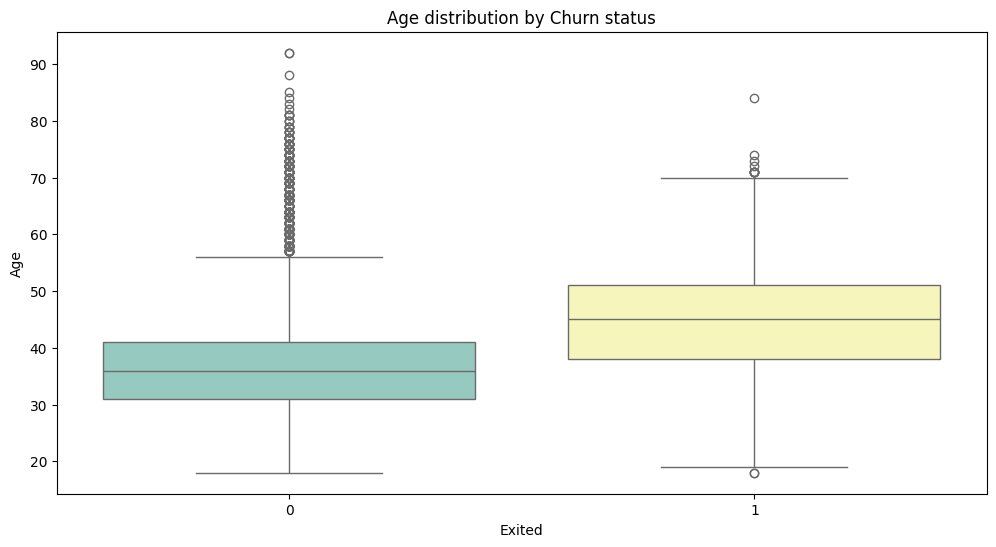

In [244]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Exited', y='Age', data=df, palette='Set3')
plt.title('Age distribution by Churn status')
plt.xlabel('Exited')
plt.ylabel('Age')
plt.savefig(r'C:\Customer_churn_prediction\coading_part\data_visulzation\Bank_Age by Exited.png')
plt.show()

C:\Users\ajsah\AppData\Local\Temp\ipykernel_11008\2825644190.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Balance', data=df, palette='Set3')


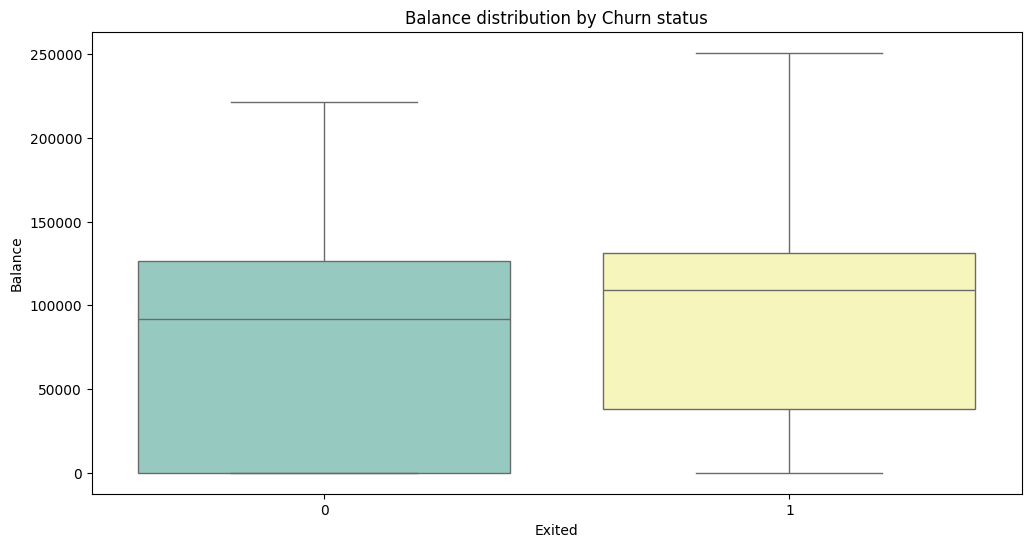

In [245]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Exited', y='Balance', data=df, palette='Set3')
plt.title('Balance distribution by Churn status')
plt.xlabel('Exited')
plt.ylabel('Balance')
plt.savefig(r'C:\Customer_churn_prediction\coading_part\data_visulzation\Bank_Balance by Exited.png')
plt.show()

C:\Users\ajsah\AppData\Local\Temp\ipykernel_11008\3786187634.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Exited', y='EstimatedSalary', data=df, palette='Set3')


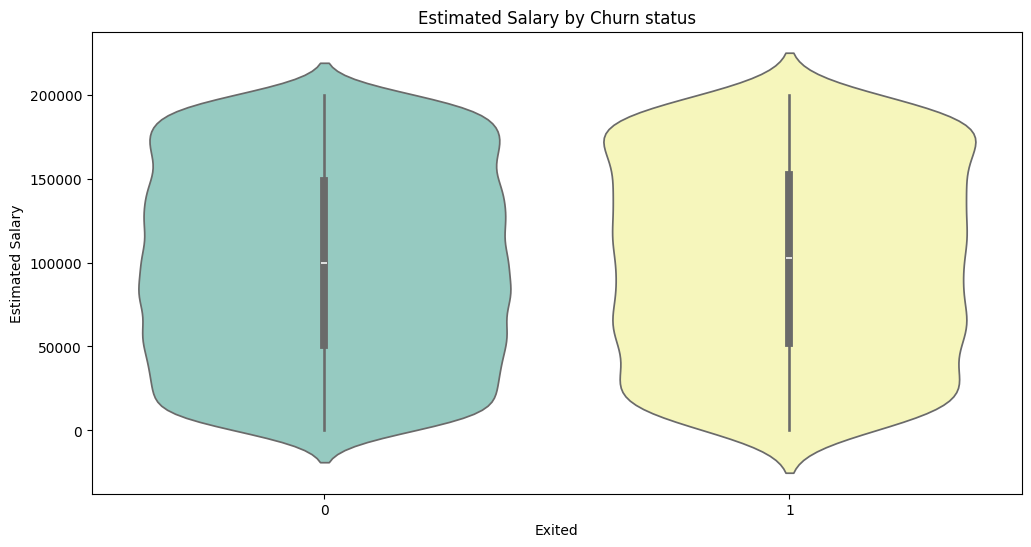

In [246]:
plt.figure(figsize=(12,6))
sns.violinplot(x='Exited', y='EstimatedSalary', data=df, palette='Set3')
plt.title('Estimated Salary by Churn status')
plt.xlabel('Exited')
plt.ylabel('Estimated Salary')
plt.savefig(r'C:\Customer_churn_prediction\coading_part\data_visulzation\Bank_Salary by Exited.png')
plt.show()

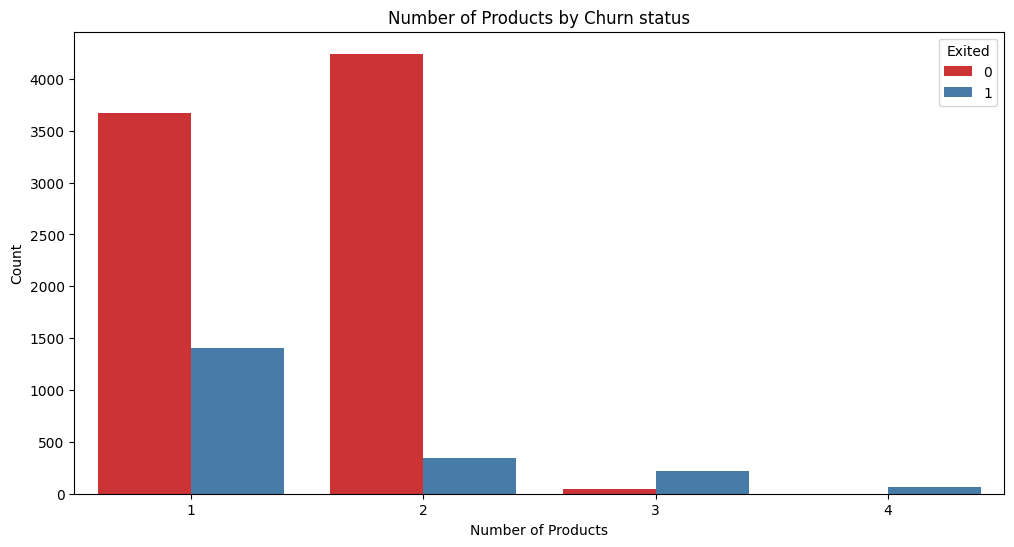

In [247]:
plt.figure(figsize=(12,6))
ax = sns.countplot(x='NumOfProducts', hue='Exited', data=df, palette='Set1')
plt.title('Number of Products by Churn status')
plt.xlabel('Number of Products')
plt.ylabel('Count')
plt.savefig(r'C:\Customer_churn_prediction\coading_part\data_visulzation\Bank_Products by Exited.png')
plt.show()

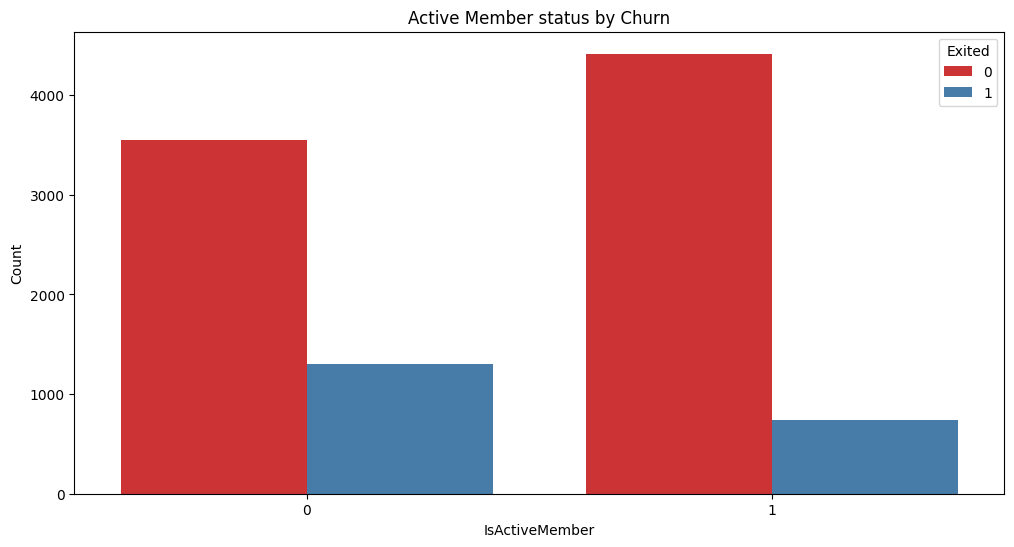

In [248]:
plt.figure(figsize=(12,6))
ax = sns.countplot(x='IsActiveMember', hue='Exited', data=df, palette='Set1')
plt.title('Active Member status by Churn')
plt.xlabel('IsActiveMember')
plt.ylabel('Count')
plt.savefig(r'C:\Customer_churn_prediction\coading_part\data_visulzation\Bank_ActiveMember by Exited.png')
plt.show()

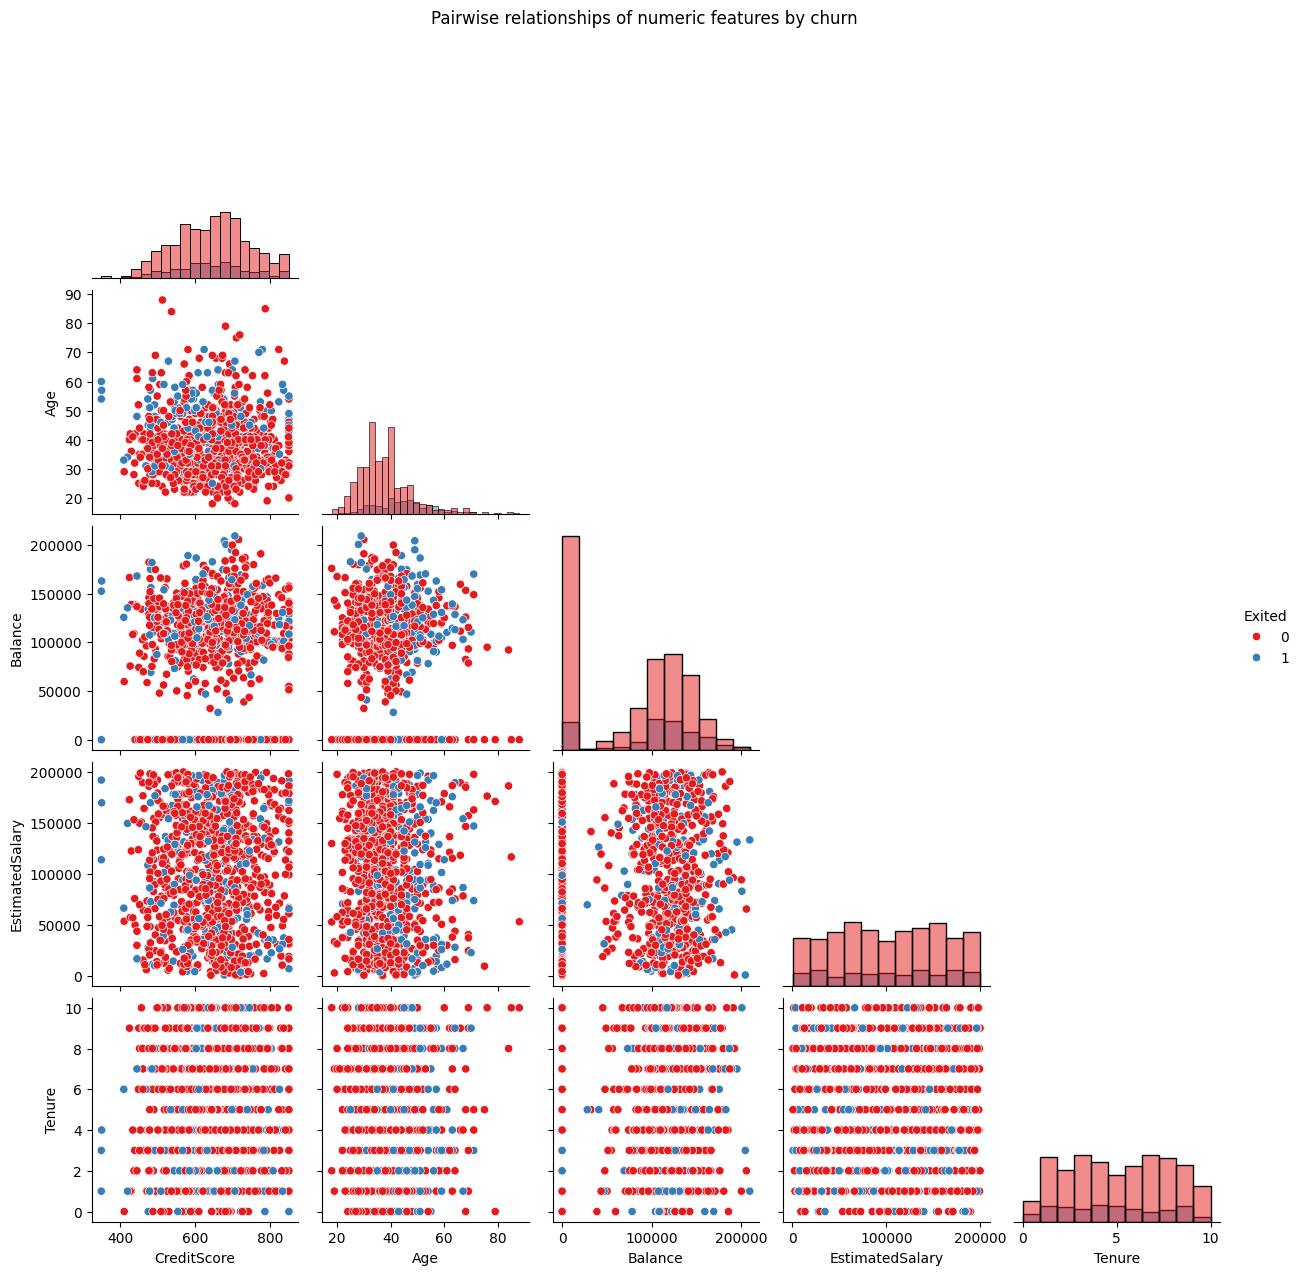

In [249]:
selected_features = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Tenure', 'Exited']
plot_sample = df[selected_features].sample(n=min(len(df), 1000), random_state=42)
sns.pairplot(plot_sample, hue='Exited', diag_kind='hist', palette='Set1', corner=True)
plt.suptitle('Pairwise relationships of numeric features by churn', y=1.02)
plt.savefig(r'C:\Customer_churn_prediction\coading_part\data_visulzation\Bank_Pairwise Relationships by Exited.png')
plt.show()

## **Pattern Observations**
- Customers who churn are more common in certain geographies and more frequent among one gender in this dataset.
- Older customers show a distinct churn distribution compared to younger customers.
- Higher balance and salary ranges have visible differences in churn behavior.
- Customers with fewer products and non-active members tend to churn more often.
- The pairwise plot highlights correlations and clusters between numeric features and churn status.

In [250]:
import numpy as np

df['Age'] = np.where(df['Age'] > upper, upper, df['Age'])
df['Age'] = np.where(df['Age'] < lower, lower, df['Age'])

In [251]:
# Convert categroical variables Gender Male and Female to replace 0, 1
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0},inplace=True)   

In [252]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)

encoded = ohe.fit_transform(df[['Geography']])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['Geography']))

# original df me add karo
df = pd.concat([df, encoded_df], axis=1)

# optional: original column hata do
df.drop('Geography', axis=1, inplace=True)

In [253]:
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42.0,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41.0,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42.0,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39.0,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43.0,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39.0,5,0.00,2,1,0,96270.64,0,1.0,0.0,0.0
9996,516,1,35.0,10,57369.61,1,1,1,101699.77,0,1.0,0.0,0.0
9997,709,0,36.0,7,0.00,1,0,1,42085.58,1,1.0,0.0,0.0
9998,772,1,42.0,3,75075.31,2,1,0,92888.52,1,0.0,1.0,0.0


In [254]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# 2. Advanced Feature Engineering [cite: 538-543]
df['Balance_to_Salary_Ratio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['Product_Density'] = df['NumOfProducts'] / (df['Tenure'] + 1)
df['Age_Active_Interaction'] = df['Age'] * df['IsActiveMember']
df['Credit_Utilization_Proxy'] = df['Balance'] / (df['CreditScore'] + 1)

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 6. Train Production Model 
# Use scale_pos_weight to address Class Imbalance
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]
model = XGBClassifier(scale_pos_weight=ratio, learning_rate=0.05, n_estimators=500, max_depth=6)
model.fit(X_train, y_train)

# 7. Evaluation
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8215
ROC-AUC: 0.8355

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.89      1593
           1       0.55      0.64      0.59       407

    accuracy                           0.82      2000
   macro avg       0.73      0.76      0.74      2000
weighted avg       0.83      0.82      0.83      2000



C:\Users\ajsah\AppData\Local\Temp\ipykernel_11008\3589940730.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


<Figure size 640x480 with 0 Axes>

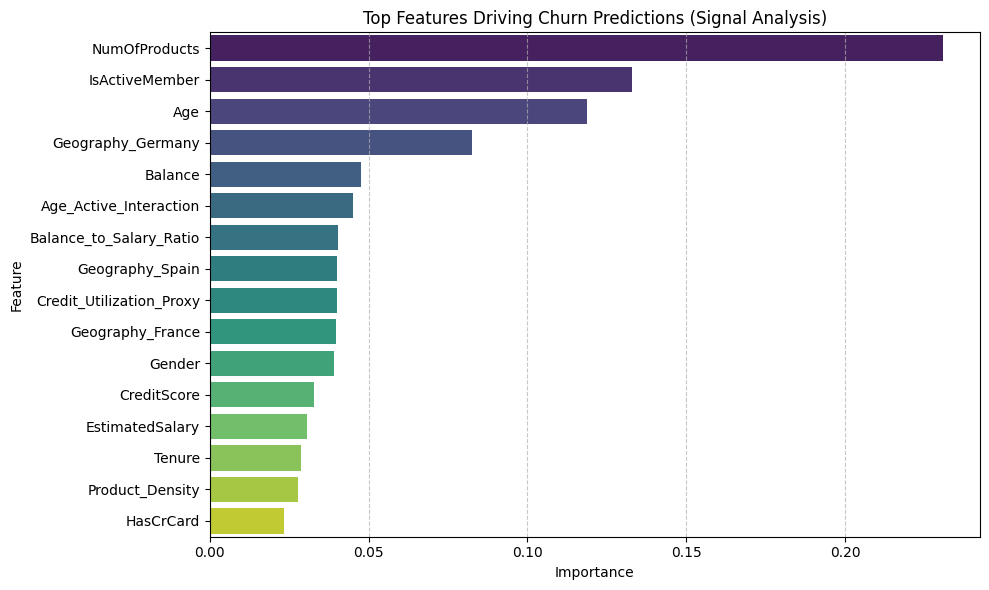

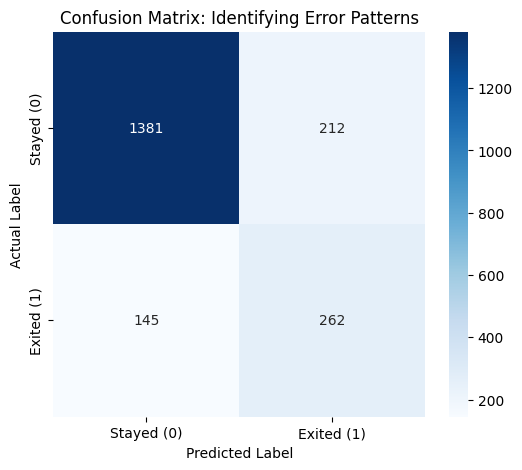

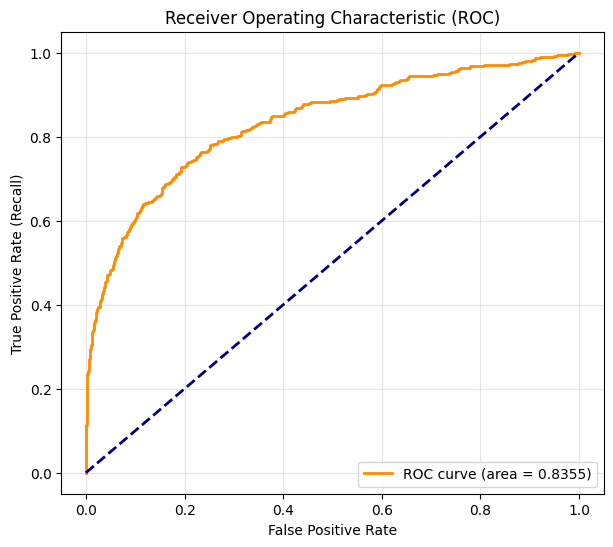

In [257]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import pandas as pd

# 1. Feature Importance: Identifying the "Signal" 
def plot_feature_importance(model, feature_names):
    importance = model.feature_importances_
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
    plt.title('Top Features Driving Churn Predictions (Signal Analysis)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Confusion Matrix: Analyzing the "Accuracy Trap" [cite: 558, 569]
def plot_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Stayed (0)', 'Exited (1)'], 
                yticklabels=['Stayed (0)', 'Exited (1)'])
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix: Identifying Error Patterns')
    plt.show()

# 3. ROC Curve: Visualizing the 0.8355 Performance [cite: 566, 571]
def plot_roc_curve(y_test, y_probs):
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

plt.savefig(r'C:\Customer_churn_prediction\coading_part\data_visulzation\bank_churn_analysis.png', bbox_inches='tight', dpi=300)
# --- EXECUTION ---
# Assuming 'model' is your trained XGBoost, 'X' contains your features, 
# and 'y_pred_proba' are the predicted probabilities.
plot_feature_importance(model, X.columns)
plot_confusion_matrix(y_test, y_pred)
plot_roc_curve(y_test, y_pred_proba)